# Factor Investing Analysis (Fama-French)
### SPY vs QQQ vs MELI

Goal: estimate factor exposures (betas) using the Fama-French 3-factor model on daily data.

Model:
Excess Return = alpha + b1*(Mkt-RF) + b2*SMB + b3*HML + error

In [6]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

import io
import zipfile
import urllib.request

In [7]:
tickers = ["SPY", "QQQ", "MELI"]

# Descarga de precios (viene con columnas MultiIndex)
raw = yf.download(tickers, start="2015-01-01", auto_adjust=False, group_by="column", progress=False)

# EXTRAEMOS Adj Close (nivel 0 del MultiIndex)
prices = raw["Adj Close"].dropna(how="all")

# Nos quedamos solo con los tickers (por seguridad)
prices = prices[tickers]

# Retornos diarios
returns = prices.pct_change().dropna()

print("Prices shape:", prices.shape)
print("Returns shape:", returns.shape)
prices.head()

Prices shape: (2808, 3)
Returns shape: (2807, 3)


Ticker,SPY,QQQ,MELI
Date,,,
2015-01-02,170.589615,94.784439,124.582520
2015-01-05,167.508850,93.394051,123.048111
2015-01-06,165.931076,92.141823,120.850471
2015-01-07,167.998764,93.329620,120.612877
2015-01-08,170.979919,95.115929,122.414551


In [9]:
import re

def load_ff_factors_daily():
    """
    Descarga Fama-French 3 Factors (Daily) desde Ken French (ZIP)
    y devuelve un DataFrame con columnas:
    ['Mkt-RF','SMB','HML','RF'] en DECIMALES (no %).

    Parser robusto: busca la primera fila que empiece con YYYYMMDD.
    """
    url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip"

    with urllib.request.urlopen(url) as resp:
        content = resp.read()

    z = zipfile.ZipFile(io.BytesIO(content))

    # Agarramos el primer .csv dentro del zip
    csv_name = [n for n in z.namelist() if n.lower().endswith(".csv")][0]
    lines = z.read(csv_name).decode("utf-8", errors="ignore").splitlines()

    # 1) Encontrar la primera línea que parezca una fila de datos: YYYYMMDD,...
    # Ej: "20150102,0.12,0.03,-0.05,0.00"
    data_start = None
    for i, line in enumerate(lines):
        s = line.strip()
        if re.match(r"^\d{8}\s*,", s):  # fecha 8 dígitos seguida de coma
            data_start = i
            break

    if data_start is None:
        # Debug útil: mostramos algunas líneas del comienzo
        preview = "\n".join(lines[:40])
        raise RuntimeError("No encontré filas con formato YYYYMMDD,. Preview:\n" + preview)

    # 2) Desde data_start, juntar líneas hasta que deje de ser tabular
    data_lines = []
    for line in lines[data_start:]:
        s = line.strip()
        if s == "":
            if len(data_lines) > 20:
                break
            continue

        # si ya no empieza con fecha, probablemente arrancó el footer (notas)
        if not re.match(r"^\d{8}\s*,", s):
            break

        data_lines.append(line)

    # 3) Leer sin header, asignar nombres
    ff = pd.read_csv(
        io.StringIO("\n".join(data_lines)),
        header=None,
        names=["Date", "Mkt-RF", "SMB", "HML", "RF"]
    )

    # 4) Parsear fecha y convertir de % a decimal
    ff["Date"] = pd.to_datetime(ff["Date"], format="%Y%m%d", errors="coerce")
    ff = ff.dropna(subset=["Date"]).set_index("Date")

    for c in ["Mkt-RF", "SMB", "HML", "RF"]:
        ff[c] = pd.to_numeric(ff[c], errors="coerce") / 100.0

    ff = ff.dropna()
    return ff
ff = load_ff_factors_daily()
print("FF factors shape:", ff.shape)
ff.head()

FF factors shape: (26171, 4)


,Mkt-RF,SMB,HML,RF
Date,,,,
1926-07-01,0.0009,-0.0025,-0.0027,0.0001
1926-07-02,0.0045,-0.0033,-0.0006,0.0001
1926-07-06,0.0017,0.0030,-0.0039,0.0001
1926-07-07,0.0009,-0.0058,0.0002,0.0001
1926-07-08,0.0022,-0.0038,0.0019,0.0001


In [10]:
# 1) Unir retornos de activos (2015+) con factores (1926+)
# inner = nos quedamos solo con las fechas en común
df = returns.join(ff, how="inner")

print("Merged df shape:", df.shape)
display(df.head())

# 2) Función para correr la regresión FF3:
# (Ri - Rf) = alpha + b1*(Mkt-RF) + b2*SMB + b3*HML + error
def run_ff3_regression(df, ticker):
    y = df[ticker] - df["RF"]                 # exceso de retorno del activo
    X = df[["Mkt-RF", "SMB", "HML"]]
    X = sm.add_constant(X)                    # agrega intercepto (alpha)
    model = sm.OLS(y, X).fit()
    return model

tickers = ["SPY", "QQQ", "MELI"]
models = {t: run_ff3_regression(df, t) for t in tickers}

# 3) Tabla resumen (para el reporte)
rows = []
for t in tickers:
    m = models[t]
    rows.append({
        "Asset": t,
        "Alpha (daily)": m.params["const"],
        "Beta_Mkt": m.params["Mkt-RF"],
        "Beta_SMB": m.params["SMB"],
        "Beta_HML": m.params["HML"],
        "R2": m.rsquared
    })

betas = pd.DataFrame(rows).set_index("Asset")
betas

Merged df shape: (2785, 7)


,SPY,QQQ,MELI,Mkt-RF,SMB,HML,RF
Date,,,,,,,
2015-01-05,-0.018060,-0.014669,-0.012316,-0.0184,0.0033,-0.0067,0.0
2015-01-06,-0.009419,-0.013408,-0.017860,-0.0103,-0.0079,-0.0029,0.0
2015-01-07,0.012461,0.012891,-0.001966,0.0119,0.0020,-0.0067,0.0
2015-01-08,0.017745,0.019140,0.014938,0.0181,-0.0011,-0.0029,0.0
2015-01-09,-0.008014,-0.006583,-0.011079,-0.0085,0.0000,-0.0047,0.0


,Alpha (daily),Beta_Mkt,Beta_SMB,Beta_HML,R2
Asset,,,,,
SPY,-0.000002,0.980391,-0.118829,0.015737,0.994403
QQQ,0.000118,1.110972,-0.121821,-0.399357,0.946897
MELI,0.000709,1.341133,0.336600,-0.847495,0.378860


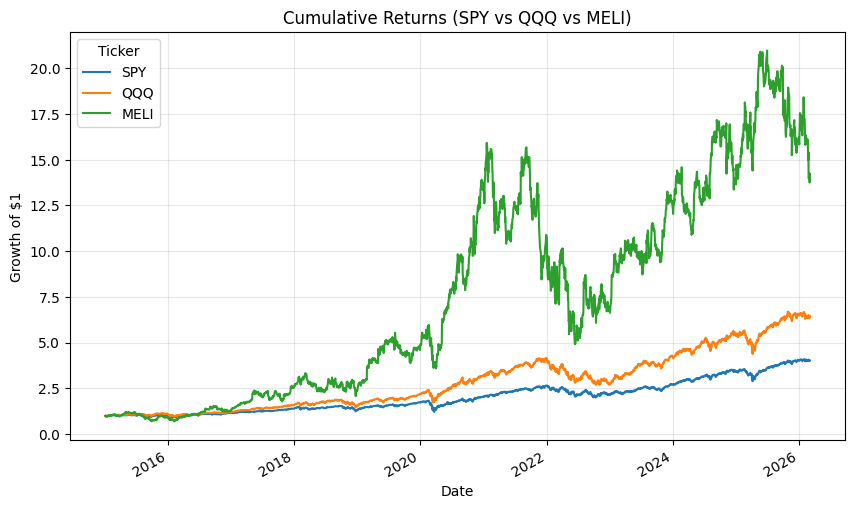

In [11]:
# Cumulative returns (desde 2015)
cum = (1 + returns).cumprod()
cum.plot(figsize=(10,6))
plt.title("Cumulative Returns (SPY vs QQQ vs MELI)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.3)
plt.show()

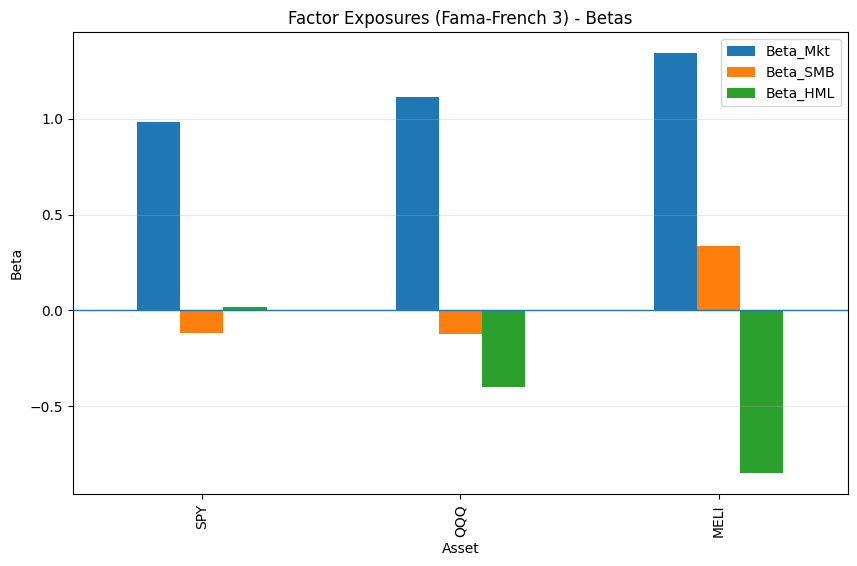

In [12]:
# Bar chart de betas (sin alpha ni R2)
betas_plot = betas[["Beta_Mkt", "Beta_SMB", "Beta_HML"]]

ax = betas_plot.plot(kind="bar", figsize=(10,6))
plt.title("Factor Exposures (Fama-French 3) - Betas")
plt.xlabel("Asset")
plt.ylabel("Beta")
plt.axhline(0, linewidth=1)
plt.grid(True, axis="y", alpha=0.3)
plt.legend(loc="best")
plt.show()

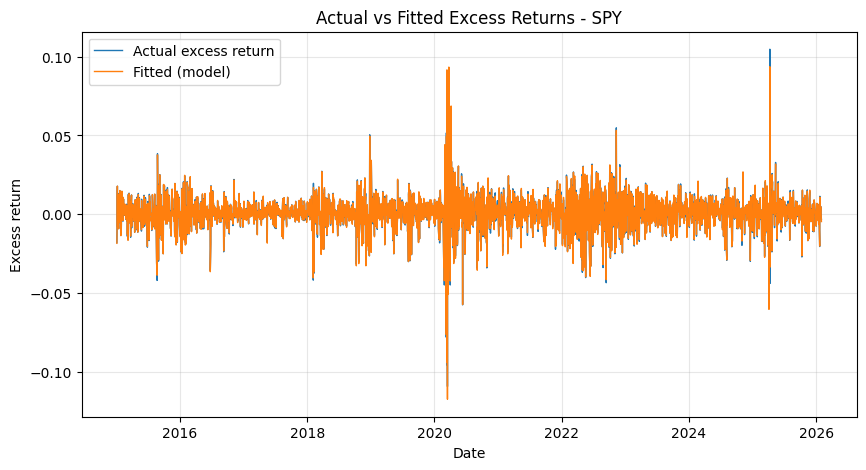

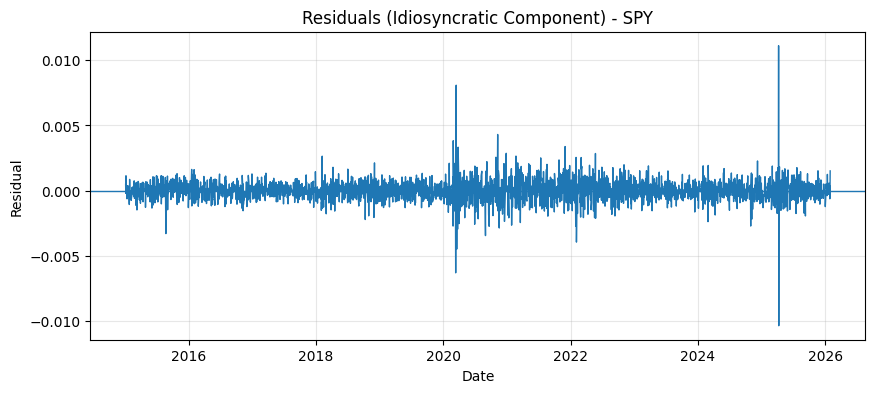

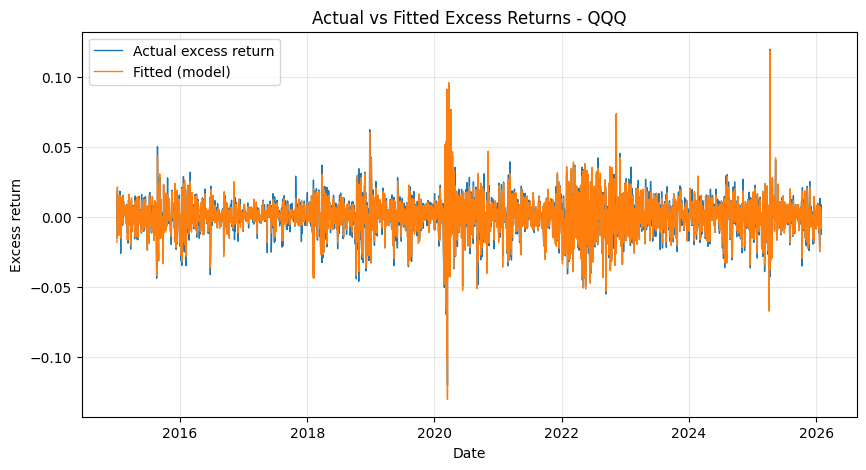

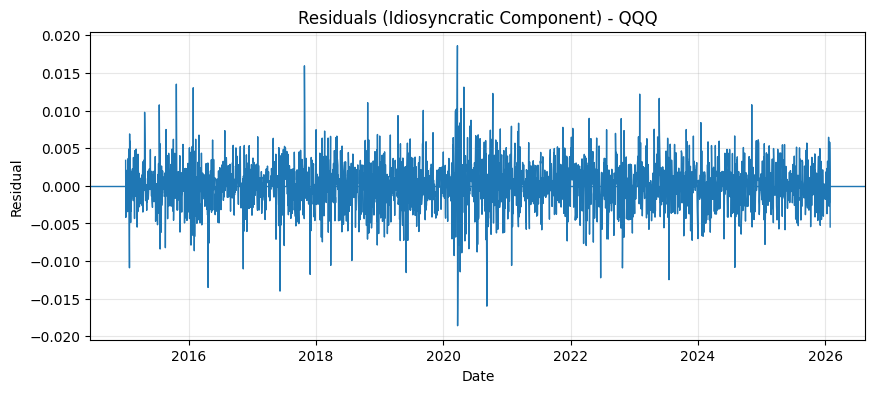

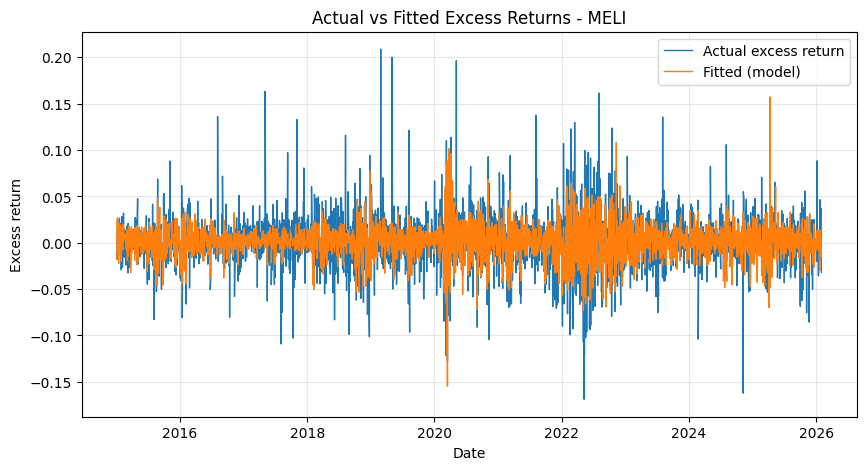

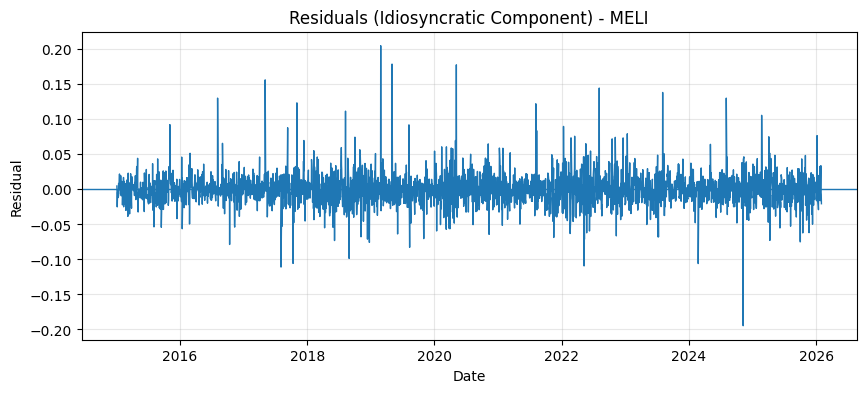

In [13]:
def plot_fitted_and_residuals(df, ticker, model):
    y = df[ticker] - df["RF"]
    fitted = model.fittedvalues
    resid = model.resid

    # 1) Actual vs Fitted
    plt.figure(figsize=(10,5))
    plt.plot(y.index, y, label="Actual excess return", linewidth=1)
    plt.plot(fitted.index, fitted, label="Fitted (model)", linewidth=1)
    plt.title(f"Actual vs Fitted Excess Returns - {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Excess return")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # 2) Residuals (serie)
    plt.figure(figsize=(10,4))
    plt.plot(resid.index, resid, linewidth=1)
    plt.title(f"Residuals (Idiosyncratic Component) - {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Residual")
    plt.axhline(0, linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.show()

# Hacemos los 3 (tarda poco)
for t in ["SPY", "QQQ", "MELI"]:
    plot_fitted_and_residuals(df, t, models[t])

In [14]:
rows = []
for t in tickers:
    m = models[t]
    rows.append({
        "Asset": t,
        "Alpha": m.params["const"],
        "Alpha p-value": m.pvalues["const"],
        "Mkt beta": m.params["Mkt-RF"],
        "Mkt p-value": m.pvalues["Mkt-RF"],
        "SMB beta": m.params["SMB"],
        "SMB p-value": m.pvalues["SMB"],
        "HML beta": m.params["HML"],
        "HML p-value": m.pvalues["HML"],
        "R2": m.rsquared
    })

signif = pd.DataFrame(rows).set_index("Asset")
signif

,Alpha,Alpha p-value,Mkt beta,Mkt p-value,SMB beta,SMB p-value,HML beta,HML p-value,R2
Asset,,,,,,,,,
SPY,-0.000002,0.877795,0.980391,0.000000e+00,-0.118829,0.000000e+00,0.015737,3.278251e-18,0.994403
QQQ,0.000118,0.051042,1.110972,0.000000e+00,-0.121821,5.593829e-37,-0.399357,0.000000e+00,0.946897
MELI,0.000709,0.111726,1.341133,2.110241e-209,0.336600,1.438050e-06,-0.847495,1.772582e-60,0.378860


In [15]:
window = 252  # ~ 1 año de trading days

factors = ["Mkt-RF", "SMB", "HML"]

def rolling_betas(df, ticker, window=252):
    """
    Calcula betas rolling usando FF3 en ventanas móviles.
    Devuelve DataFrame con columnas: const, Mkt-RF, SMB, HML
    """
    y = df[ticker] - df["RF"]
    X = df[factors]
    X = sm.add_constant(X)

    betas = []
    idx = []

    # recorremos desde el final de la primera ventana
    for end in range(window, len(df) + 1):
        y_w = y.iloc[end-window:end]
        X_w = X.iloc[end-window:end]
        model = sm.OLS(y_w, X_w).fit()
        betas.append(model.params)
        idx.append(df.index[end-1])

    betas_df = pd.DataFrame(betas, index=idx)
    betas_df.index.name = "Date"
    return betas_df

rolling = {t: rolling_betas(df, t, window=window) for t in tickers}

# Mostrar un vistazo
for t in tickers:
    print(t, rolling[t].shape)
    display(rolling[t].head())

SPY (2534, 4)


,const,Mkt-RF,SMB,HML
Date,,,,
2016-01-04,0.000017,0.993896,-0.134562,-0.015338
2016-01-05,0.000016,0.994349,-0.134739,-0.014792
2016-01-06,0.000019,0.993893,-0.135340,-0.015055
2016-01-07,0.000015,0.993661,-0.135420,-0.014360
2016-01-08,0.000015,0.994305,-0.134935,-0.014367


QQQ (2534, 4)


,const,Mkt-RF,SMB,HML
Date,,,,
2016-01-04,0.000126,1.075232,-0.239205,-0.490715
2016-01-05,0.000102,1.077084,-0.238875,-0.488261
2016-01-06,0.000140,1.071563,-0.248836,-0.492956
2016-01-07,0.000129,1.078721,-0.244973,-0.495029
2016-01-08,0.000147,1.079279,-0.247351,-0.496365


MELI (2534, 4)


,const,Mkt-RF,SMB,HML
Date,,,,
2016-01-04,-0.000231,1.215812,0.400235,0.068137
2016-01-05,-0.000278,1.223306,0.398652,0.077448
2016-01-06,-0.000289,1.224954,0.397353,0.076447
2016-01-07,-0.000264,1.242917,0.406434,0.062657
2016-01-08,-0.000244,1.248833,0.406971,0.060730


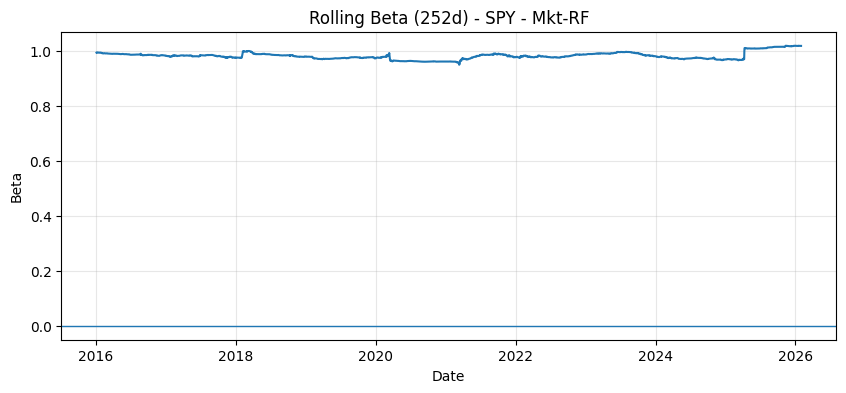

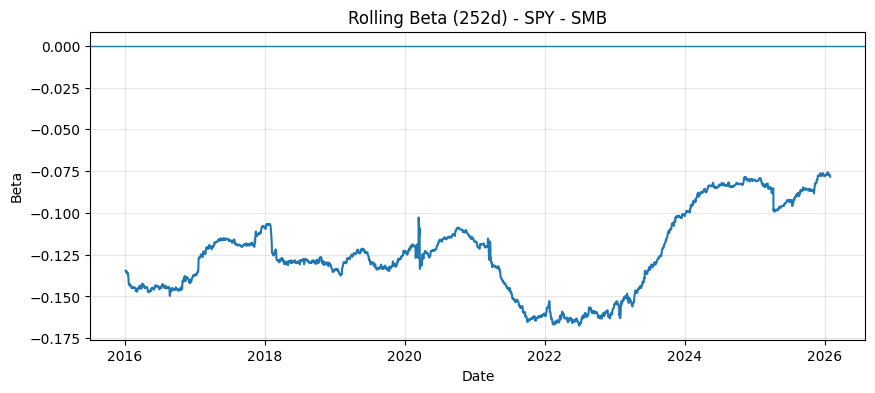

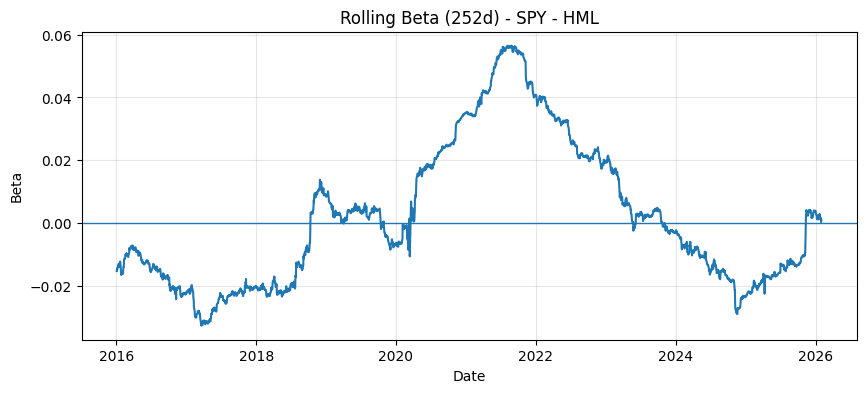

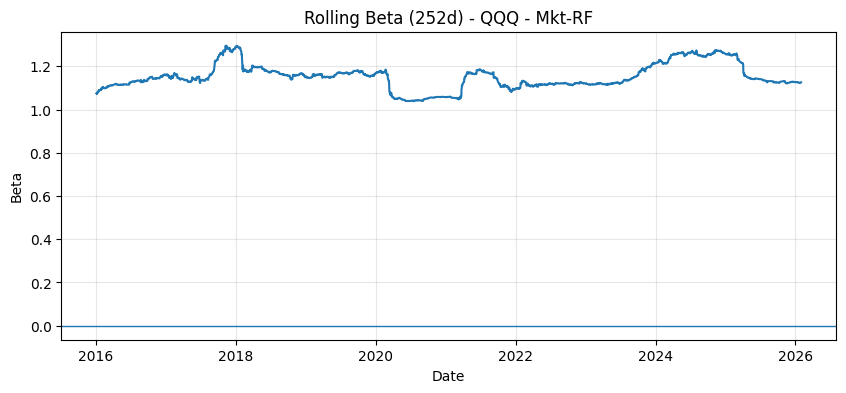

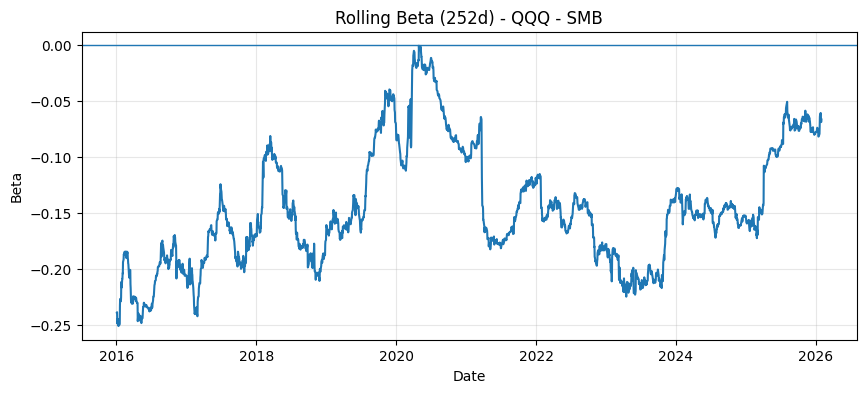

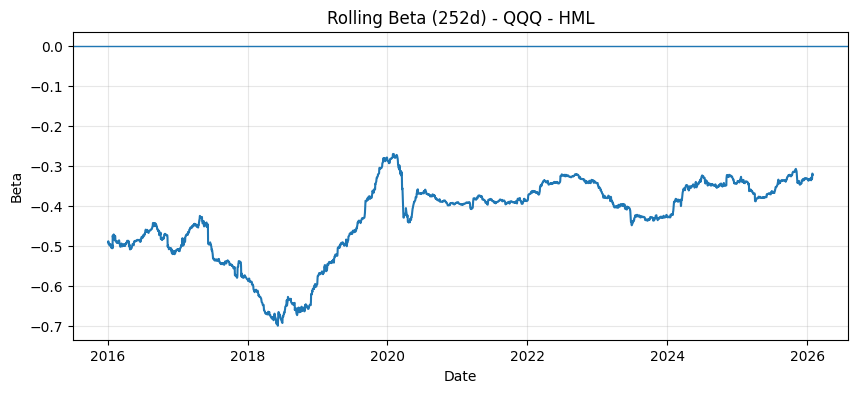

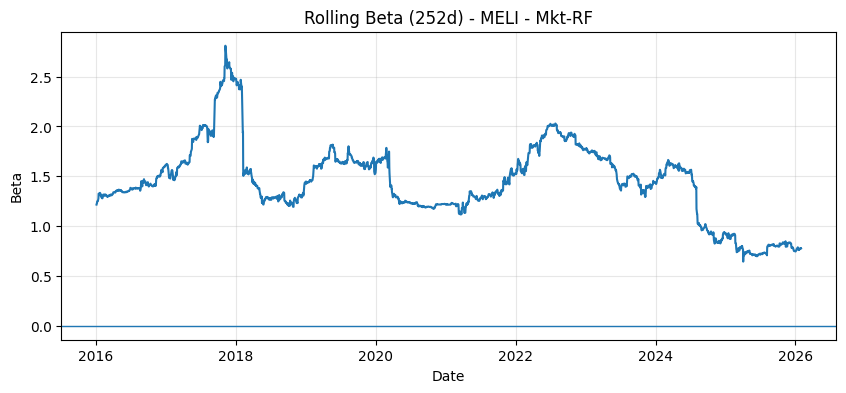

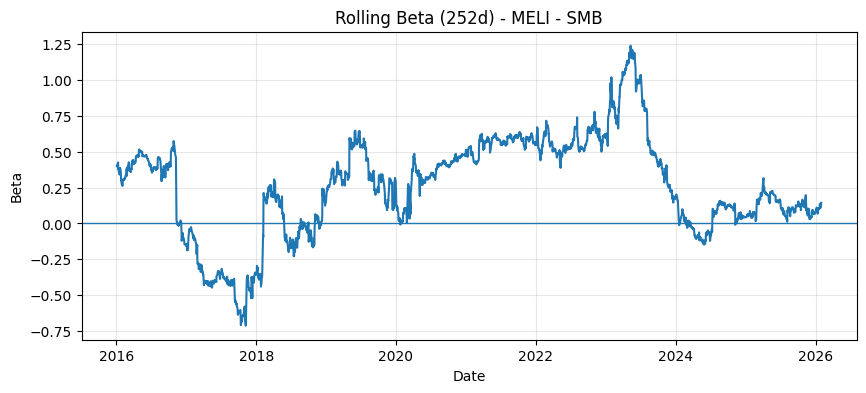

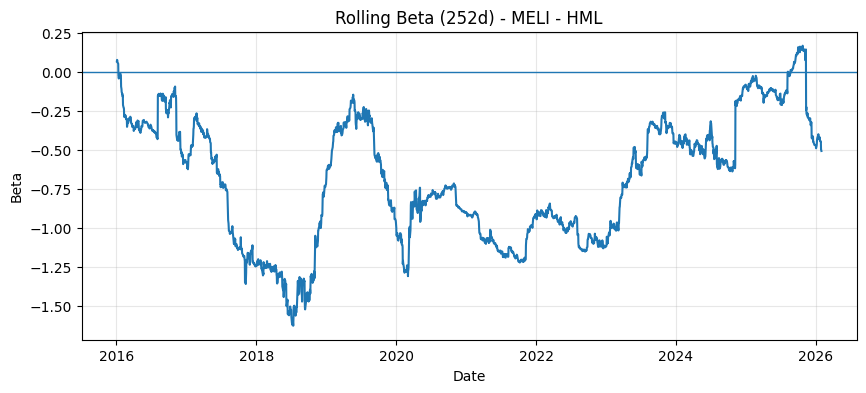

In [16]:
def plot_rolling_betas(roll_df, ticker):
    for col in ["Mkt-RF", "SMB", "HML"]:
        plt.figure(figsize=(10,4))
        plt.plot(roll_df.index, roll_df[col])
        plt.title(f"Rolling Beta ({window}d) - {ticker} - {col}")
        plt.xlabel("Date")
        plt.ylabel("Beta")
        plt.axhline(0, linewidth=1)
        plt.grid(True, alpha=0.3)
        plt.show()

for t in tickers:
    plot_rolling_betas(rolling[t], t)

In [17]:
contrib = {}

for t in tickers:
    m = models[t]
    alpha = m.params["const"]
    b = m.params[["Mkt-RF", "SMB", "HML"]]

    # contribuciones diarias
    c_mkt = b["Mkt-RF"] * df["Mkt-RF"]
    c_smb = b["SMB"] * df["SMB"]
    c_hml = b["HML"] * df["HML"]
    c_alpha = pd.Series(alpha, index=df.index)

    # fitted total
    fitted = c_alpha + c_mkt + c_smb + c_hml

    contrib[t] = pd.DataFrame({
        "alpha": c_alpha,
        "mkt": c_mkt,
        "smb": c_smb,
        "hml": c_hml,
        "fitted_excess": fitted,
        "actual_excess": df[t] - df["RF"]
    })

# vistazo
contrib["SPY"].head()

,alpha,mkt,smb,hml,fitted_excess,actual_excess
Date,,,,,,
2015-01-05,-0.000002,-0.018039,-0.000392,-0.000105,-0.018539,-0.018060
2015-01-06,-0.000002,-0.010098,0.000939,-0.000046,-0.009207,-0.009419
2015-01-07,-0.000002,0.011667,-0.000238,-0.000105,0.011321,0.012461
2015-01-08,-0.000002,0.017745,0.000131,-0.000046,0.017828,0.017745
2015-01-09,-0.000002,-0.008333,-0.000000,-0.000074,-0.008410,-0.008014


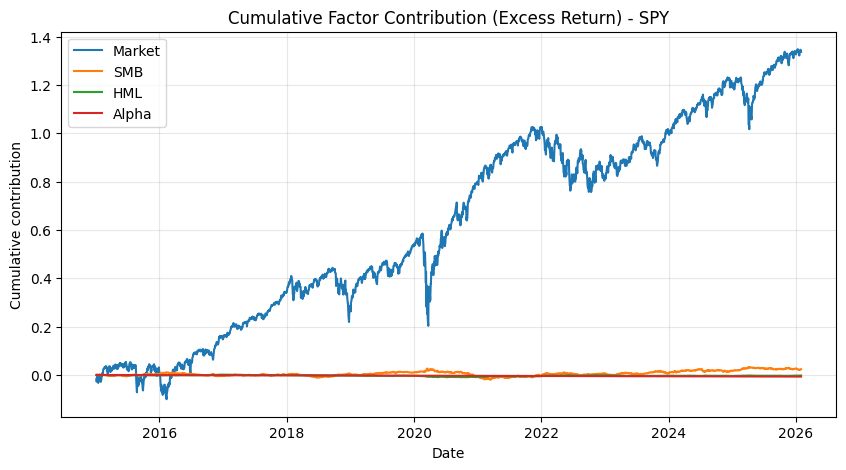

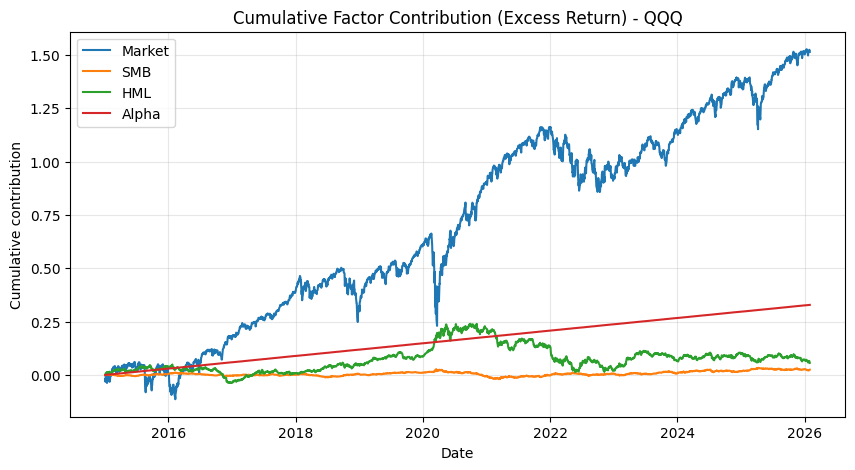

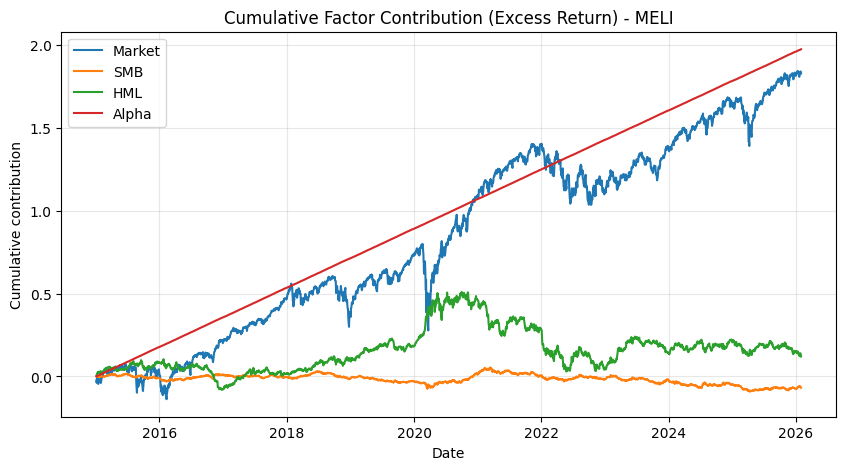

In [18]:
def plot_cumulative_contribution(contrib_df, ticker):
    cum = contrib_df[["alpha","mkt","smb","hml"]].cumsum()

    plt.figure(figsize=(10,5))
    plt.plot(cum.index, cum["mkt"], label="Market")
    plt.plot(cum.index, cum["smb"], label="SMB")
    plt.plot(cum.index, cum["hml"], label="HML")
    plt.plot(cum.index, cum["alpha"], label="Alpha")
    plt.title(f"Cumulative Factor Contribution (Excess Return) - {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative contribution")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

for t in tickers:
    plot_cumulative_contribution(contrib[t], t)

In [19]:
def run_capm_regression(df, ticker):
    y = df[ticker] - df["RF"]          # exceso de retorno
    X = df[["Mkt-RF"]]
    X = sm.add_constant(X)             # alpha
    model = sm.OLS(y, X).fit()
    return model

capm_models = {t: run_capm_regression(df, t) for t in tickers}

comparison_rows = []
for t in tickers:
    capm = capm_models[t]
    ff3 = models[t]

    comparison_rows.append({
        "Asset": t,
        "CAPM_R2": capm.rsquared,
        "FF3_R2": ff3.rsquared,
        "R2_Improvement": ff3.rsquared - capm.rsquared,
        "CAPM_Alpha": capm.params["const"],
        "FF3_Alpha": ff3.params["const"]
    })

comparison = pd.DataFrame(comparison_rows).set_index("Asset")
comparison

,CAPM_R2,FF3_R2,R2_Improvement,CAPM_Alpha,FF3_Alpha
Asset,,,,,
SPY,0.989669,0.994403,0.004734,0.000013,-0.000002
QQQ,0.877965,0.946897,0.068932,0.000142,0.000118
MELI,0.311206,0.378860,0.067654,0.000679,0.000709


In [20]:
def run_capm_regression(df, ticker):
    y = df[ticker] - df["RF"]          # exceso de retorno
    X = df[["Mkt-RF"]]
    X = sm.add_constant(X)             # alpha
    model = sm.OLS(y, X).fit()
    return model

capm_models = {t: run_capm_regression(df, t) for t in tickers}

comparison_rows = []
for t in tickers:
    capm = capm_models[t]
    ff3 = models[t]

    comparison_rows.append({
        "Asset": t,
        "CAPM_R2": capm.rsquared,
        "FF3_R2": ff3.rsquared,
        "R2_Improvement": ff3.rsquared - capm.rsquared,
        "CAPM_Alpha": capm.params["const"],
        "FF3_Alpha": ff3.params["const"]
    })

comparison = pd.DataFrame(comparison_rows).set_index("Asset")
comparison

,CAPM_R2,FF3_R2,R2_Improvement,CAPM_Alpha,FF3_Alpha
Asset,,,,,
SPY,0.989669,0.994403,0.004734,0.000013,-0.000002
QQQ,0.877965,0.946897,0.068932,0.000142,0.000118
MELI,0.311206,0.378860,0.067654,0.000679,0.000709


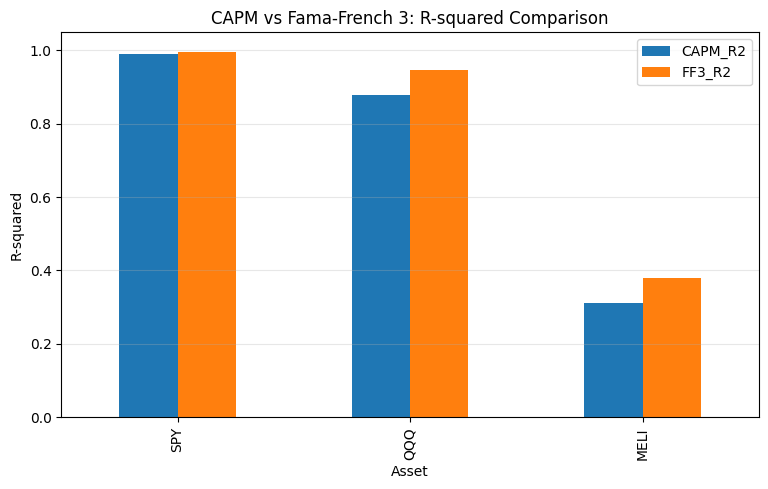

In [21]:
comparison[["CAPM_R2", "FF3_R2"]].plot(kind="bar", figsize=(9,5))
plt.title("CAPM vs Fama-French 3: R-squared Comparison")
plt.xlabel("Asset")
plt.ylabel("R-squared")
plt.ylim(0, 1.05)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

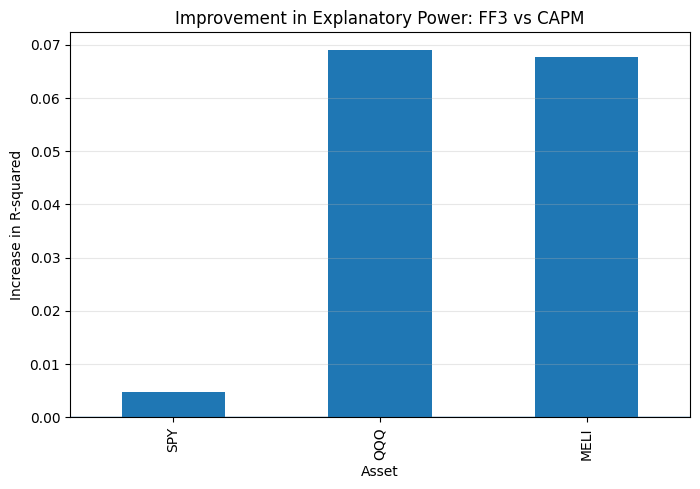

In [22]:
comparison["R2_Improvement"].plot(kind="bar", figsize=(8,5))
plt.title("Improvement in Explanatory Power: FF3 vs CAPM")
plt.xlabel("Asset")
plt.ylabel("Increase in R-squared")
plt.axhline(0, linewidth=1)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## Conclusion

This project applied the Fama-French three-factor model to analyze the factor exposures of SPY, QQQ and MELI.

The results show that:

- SPY behaves as a broad market proxy, with returns almost entirely explained by the market factor.
- QQQ exhibits a strong growth tilt, which is captured by the negative loading on the HML factor.
- MELI displays high market sensitivity and strong growth exposure, but a large portion of its returns remains idiosyncratic.

Comparing CAPM with the Fama-French model reveals that additional factors significantly improve explanatory power for growth-oriented assets like QQQ and MELI, while the improvement is limited for broad market indices such as SPY.

Overall, the analysis highlights the usefulness of multi-factor models for understanding the drivers of asset returns and portfolio risk.